In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

In [3]:
# 1. Thiết lập thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


In [4]:
!pip install kagglehub -q

import kagglehub
import shutil
import os

# 1. Tải dataset về ổ cứng tạm của Colab (rất nhanh)
print("Đang tải dataset từ Kaggle...")
path = kagglehub.dataset_download("andrewmvd/medical-mnist")
print("Đã tải xong tại:", path)

# 2. Tạo thư mục đích trên Google Drive (nếu chưa có)
drive_dir = '/content/drive/MyDrive/MNIST'
os.makedirs(drive_dir, exist_ok=True)

# 3. Nén toàn bộ thư mục thành file y_khoa.zip và lưu thẳng lên Drive
zip_path = f"{drive_dir}/medical_dataset.zip"
print(f"Đang nén và lưu lên Drive tại: {zip_path}...")
shutil.make_archive(zip_path.replace('.zip', ''), 'zip', path)
print("Hoàn tất! Bạn đã có file nén an toàn trên Google Drive.")

Đang tải dataset từ Kaggle...


100%|██████████| 84.8M/84.8M [00:05<00:00, 16.1MB/s]

Extracting files...


Đã tải xong tại: /root/.cache/kagglehub/datasets/andrewmvd/medical-mnist/versions/1
Đang nén và lưu lên Drive tại: /content/drive/MyDrive/MNIST/medical_dataset.zip...
Hoàn tất! Bạn đã có file nén an toàn trên Google Drive.


In [5]:
# Lệnh bash giải nén im lặng (-q) vào thư mục cục bộ
!unzip -q /content/drive/MyDrive/MNIST/medical_dataset.zip -d /content/dataset/medical/
print("Giải nén hoàn tất vào ổ cục bộ!")

checkdir:  cannot create extraction directory: /content/dataset/medical
           No such file or directory
Giải nén hoàn tất vào ổ cục bộ!


In [6]:
# 2. Chuẩn bị dữ liệu và Augmentation chuyên biệt cho Medical
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # Ép về 1 kênh màu
    transforms.Resize((28, 28)),                 # Đảm bảo kích thước 28x28
    transforms.ToTensor(),
    transforms.Normalize((0.3583,), (0.2746,))   # Mean và Std đặc thù của Medical MNIST
])

# Đọc toàn bộ dữ liệu từ thư mục gốc
# dataset_path = '/content/dataset/medical'
# full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
full_dataset = datasets.ImageFolder(root=path, transform=transform)

# Hiển thị các lớp (sẽ tự động map theo tên thư mục)
classes = full_dataset.classes
print(f"Các lớp phát hiện được: {classes}")

# Chia dữ liệu: 80% Train, 20% Test
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print(f"Số lượng mẫu Train: {len(train_dataset)}")
print(f"Số lượng mẫu Test: {len(test_dataset)}")

Các lớp phát hiện được: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']
Số lượng mẫu Train: 47163
Số lượng mẫu Test: 11791


In [7]:
# 3. Định nghĩa hàm Focal Loss (Giải quyết mất cân bằng & Độ khó lớp)
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss) # Lấy xác suất của lớp đúng
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        else:
            return focal_loss.sum()

In [8]:
# 4. Định nghĩa mạng ANN cho Medical (Tập trung độ ổn định với BatchNorm)
class ANN_Medical(nn.Module):
    def __init__(self):
        super(ANN_Medical, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 6) # Medical có 6 lớp
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.network(x)
        return logits

In [9]:
model = ANN_Medical().to(device)
criterion = FocalLoss(gamma=2.0) # Thay CrossEntropyLoss bằng FocalLoss
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
# Lưu trữ Metrics
train_losses = []
train_accuracies = []

# 5. Vòng lặp Huấn luyện kết hợp Đánh giá
epochs = 25
print("\nBắt đầu quá trình huấn luyện Medical MNIST với Focal Loss...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = 100 * correct_train / total_train

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    print(f"Epoch [{epoch+1:02d}/{epochs:02d}] | "
          f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}%")

print("\nHoàn thành huấn luyện!")


Bắt đầu quá trình huấn luyện Medical MNIST với Focal Loss...
Epoch [01/25] | Train Loss: 0.0133 - Train Acc: 99.17%
Epoch [02/25] | Train Loss: 0.0026 - Train Acc: 99.77%
Epoch [03/25] | Train Loss: 0.0017 - Train Acc: 99.84%
Epoch [04/25] | Train Loss: 0.0012 - Train Acc: 99.88%
Epoch [05/25] | Train Loss: 0.0020 - Train Acc: 99.80%
Epoch [06/25] | Train Loss: 0.0009 - Train Acc: 99.89%
Epoch [07/25] | Train Loss: 0.0009 - Train Acc: 99.90%
Epoch [08/25] | Train Loss: 0.0011 - Train Acc: 99.89%
Epoch [09/25] | Train Loss: 0.0009 - Train Acc: 99.92%
Epoch [10/25] | Train Loss: 0.0007 - Train Acc: 99.92%
Epoch [11/25] | Train Loss: 0.0010 - Train Acc: 99.91%
Epoch [12/25] | Train Loss: 0.0005 - Train Acc: 99.94%
Epoch [13/25] | Train Loss: 0.0004 - Train Acc: 99.95%
Epoch [14/25] | Train Loss: 0.0010 - Train Acc: 99.89%
Epoch [15/25] | Train Loss: 0.0006 - Train Acc: 99.92%
Epoch [16/25] | Train Loss: 0.0011 - Train Acc: 99.89%
Epoch [17/25] | Train Loss: 0.0006 - Train Acc: 99.93%
Epo

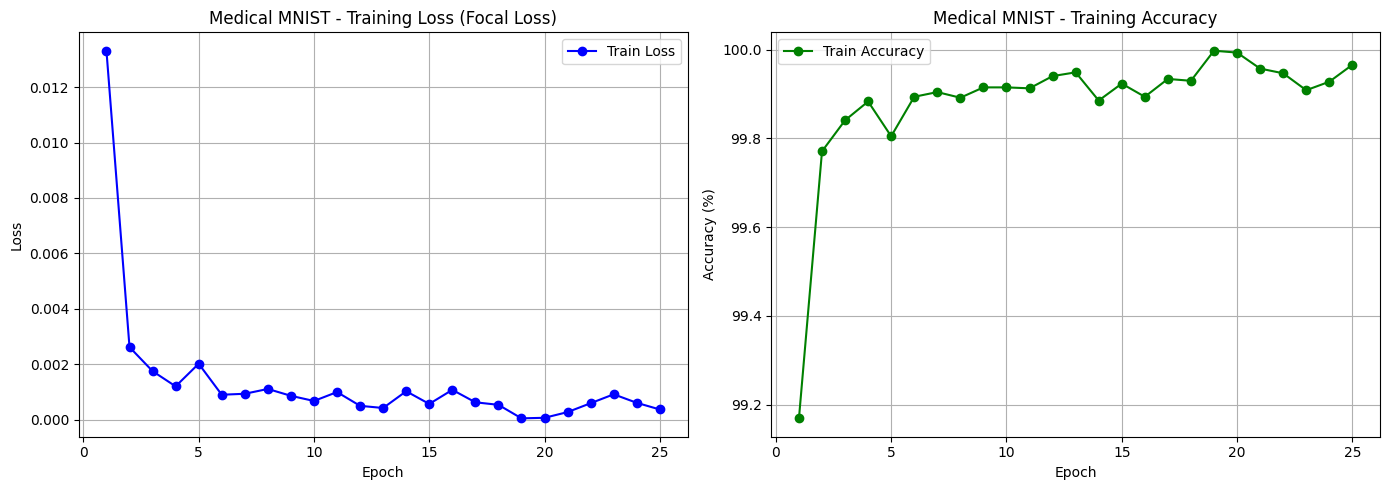

In [11]:
# 6. Visualization
plt.figure(figsize=(14, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, label='Train Loss', color='blue', marker='o')
plt.title('Medical MNIST - Training Loss (Focal Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accuracies, label='Train Accuracy', color='green', marker='o')
plt.title('Medical MNIST - Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
# 7. Đánh giá Độc lập trên tập Test
print("\n--- ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
model.eval()
test_running_loss = 0.0
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

final_loss = test_running_loss / total_test
final_acc = 100 * correct_test / total_test

print(f"Kết quả kiểm thử:")
print(f" > Test Loss: {final_loss:.4f}")
print(f" > Test Accuracy: {final_acc:.2f}%")


--- ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---
Kết quả kiểm thử:
 > Test Loss: 0.0011
 > Test Accuracy: 99.92%
